## Work in progress introduction

As explained in the ReadMe due to the innovative nature of the Agentic Payment space, we have not been able to find public datasets to use for this Capstone Project.
However, we were able to use Google Gemini to create Python code which would create sample datasets with payment transaction flows resulting in JSON roundtrip flows.
These JSON files created simulate 10.000 records with 5% of supposedly fraudulent transactions.  These fraudulent transactions include certain characteristics which we are not sure of yet, but we will use EDA, visualization and ML to try to identify these patters and then create a model to help identify future fraudulent Agentic Payment transactions.

In this work in progress workbook, we analyze the data and eliminate the useless features, and eliminate the features that would not be present in a transaction BEFORE it is sent to the payment processor.  

In [1]:
# load dataset from json file into a DataFrame
from pathlib import Path
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler


json_path = Path("acp_mixed_outcomes_w_noise.json")

if not json_path.exists():
    raise FileNotFoundError(
        f"Could not find {json_path.name} in {Path.cwd()}"
    )

with json_path.open("r", encoding="utf-8") as f:
    dataset = json.load(f)

df = pd.json_normalize(dataset)
# display the first few rows of the DataFrame
df.head()

,transaction_id,timestamp,outcome_metadata.simulation_label,outcome_metadata.risk_score,initiation.acp_version,initiation.agent.id,initiation.agent.provider,initiation.cart.items,initiation.shipping_address.postal_code,initiation.shipping_address.country,...,proposal.totals.tax,proposal.totals.total,proposal.totals.currency,settlement.action,settlement.payment_token.token_id,settlement.payment_token.network_provider,settlement.payment_token.scoped_amount,settlement.payment_token.currency,settlement.buyer_verification.protocol,settlement.buyer_verification.mandate_signature
0,tx_acp_c628f566022a,2026-10-07T22:28:21Z,approved,10,2026-04-17,agent_chatgpt_v5,AI_Corp,"[{'sku': 'sku_wireless_buds_v2', 'quantity': 2...",43960,US,...,14.85,194.83,USD,payment_settled,spt_live_a0da42858444408,stripe_acp_v1,194.83,USD,AP2,sig_ed25519_44c9c7d607
1,tx_acp_ddaaa6cc2a64,2026-10-08T12:03:21Z,approved,10,2026-04-17,agent_chatgpt_v5,AI_Corp,"[{'sku': 'sku_vintage_tee_gr_l', 'quantity': 2...",21013,US,...,4.29,61.29,USD,payment_settled,spt_live_7dbe22ef6cbe4a5,stripe_acp_v1,61.29,USD,AP2,sig_ed25519_62db8e4b24
2,tx_acp_36bad9ae0e41,2026-10-08T01:24:21Z,flagged_fraud_signature_spoof,75,2026-04-17,agent_chatgpt_v5,AI_Corp,"[{'sku': 'sku_vintage_tee_gr_l', 'quantity': 2...",76166,US,...,4.29,61.29,USD,gateway_rejected,spt_hijacked_or_expired,stripe_acp_v1,61.29,USD,AP2,sig_ed25519_f06b23748f
3,tx_acp_fba70b403661,2026-10-08T09:22:21Z,approved,7,2026-04-17,agent_claude_v4,AI_Corp,"[{'sku': 'sku_vintage_tee_gr_l', 'quantity': 1...",19337,US,...,2.15,33.15,USD,payment_settled,spt_live_128c2575c9fa44a,stripe_acp_v1,33.15,USD,AP2,sig_ed25519_d2015f291c
4,tx_acp_44291d2914ee,2026-10-07T20:41:21Z,approved,14,2026-04-17,agent_claude_v4,AI_Corp,"[{'sku': 'sku_vintage_tee_gr_l', 'quantity': 2...",30209,US,...,4.29,61.29,USD,payment_settled,spt_live_52306c42f22f4b8,stripe_acp_v1,61.29,USD,AP2,sig_ed25519_45096d5183


In [2]:
# display summary statistics of the DataFrame
df.describe()

,outcome_metadata.risk_score,proposal.totals.subtotal,proposal.totals.shipping,proposal.totals.tax,proposal.totals.total,settlement.payment_token.scoped_amount
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,19.688680,274.585185,2.852200,22.654408,482.569099,295.272977
std,29.253302,856.118864,2.475091,70.629728,5334.072787,918.742066
min,0.000000,26.000000,0.000000,2.150000,33.150000,0.010000
25%,4.000000,52.000000,0.000000,4.290000,61.290000,33.150000
50%,9.000000,89.990000,5.000000,7.420000,102.410000,61.290000
75%,14.000000,179.980000,5.000000,14.850000,194.830000,194.830000
max,100.000000,5995.000000,5.000000,494.590000,299750.000000,6489.590000


In [3]:
# display information about the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   transaction_id                                   50000 non-null  object 
 1   timestamp                                        50000 non-null  object 
 2   outcome_metadata.simulation_label                50000 non-null  object 
 3   outcome_metadata.risk_score                      50000 non-null  int64  
 4   initiation.acp_version                           50000 non-null  object 
 5   initiation.agent.id                              50000 non-null  object 
 6   initiation.agent.provider                        50000 non-null  object 
 7   initiation.cart.items                            50000 non-null  object 
 8   initiation.shipping_address.postal_code          50000 non-null  object 
 9   initiation.shipping_address.

In [4]:
# show unique values in selected columns to understand the distribution of categorical data
print(df["initiation.acp_version"].unique())
print(df["initiation.agent.id"].unique())
print(df["initiation.agent.provider"].unique())
print(df["initiation.shipping_address.country"].unique())
print(df["proposal.status"].unique())
print(df["outcome_metadata.simulation_label"].unique())
print(df["settlement.action"].unique())
print(df["settlement.payment_token.network_provider"].unique())
# settlement.buyer_verification.protocol
print(df["settlement.buyer_verification.protocol"].unique())
    

['2026-04-17']
['agent_chatgpt_v5' 'agent_claude_v4' 'unknown_bot_net']
['AI_Corp']
['US']
['proposal_created' 'security_flagged']
['approved' 'flagged_fraud_signature_spoof' 'declined_insufficient_funds'
 'declined_velocity_limit_exceeded' 'flagged_fraud_token_hijack'
 'declined_card_expired' 'flagged_fraud_velocity_attack']
['payment_settled' 'gateway_rejected' 'payment_failed']
['stripe_acp_v1']
['AP2']


In [5]:
# convert timestamp column to datetime to facilitate time-based analysis
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
df.head()


,transaction_id,timestamp,outcome_metadata.simulation_label,outcome_metadata.risk_score,initiation.acp_version,initiation.agent.id,initiation.agent.provider,initiation.cart.items,initiation.shipping_address.postal_code,initiation.shipping_address.country,...,proposal.totals.tax,proposal.totals.total,proposal.totals.currency,settlement.action,settlement.payment_token.token_id,settlement.payment_token.network_provider,settlement.payment_token.scoped_amount,settlement.payment_token.currency,settlement.buyer_verification.protocol,settlement.buyer_verification.mandate_signature
0,tx_acp_c628f566022a,2026-10-07 22:28:21+00:00,approved,10,2026-04-17,agent_chatgpt_v5,AI_Corp,"[{'sku': 'sku_wireless_buds_v2', 'quantity': 2...",43960,US,...,14.85,194.83,USD,payment_settled,spt_live_a0da42858444408,stripe_acp_v1,194.83,USD,AP2,sig_ed25519_44c9c7d607
1,tx_acp_ddaaa6cc2a64,2026-10-08 12:03:21+00:00,approved,10,2026-04-17,agent_chatgpt_v5,AI_Corp,"[{'sku': 'sku_vintage_tee_gr_l', 'quantity': 2...",21013,US,...,4.29,61.29,USD,payment_settled,spt_live_7dbe22ef6cbe4a5,stripe_acp_v1,61.29,USD,AP2,sig_ed25519_62db8e4b24
2,tx_acp_36bad9ae0e41,2026-10-08 01:24:21+00:00,flagged_fraud_signature_spoof,75,2026-04-17,agent_chatgpt_v5,AI_Corp,"[{'sku': 'sku_vintage_tee_gr_l', 'quantity': 2...",76166,US,...,4.29,61.29,USD,gateway_rejected,spt_hijacked_or_expired,stripe_acp_v1,61.29,USD,AP2,sig_ed25519_f06b23748f
3,tx_acp_fba70b403661,2026-10-08 09:22:21+00:00,approved,7,2026-04-17,agent_claude_v4,AI_Corp,"[{'sku': 'sku_vintage_tee_gr_l', 'quantity': 1...",19337,US,...,2.15,33.15,USD,payment_settled,spt_live_128c2575c9fa44a,stripe_acp_v1,33.15,USD,AP2,sig_ed25519_d2015f291c
4,tx_acp_44291d2914ee,2026-10-07 20:41:21+00:00,approved,14,2026-04-17,agent_claude_v4,AI_Corp,"[{'sku': 'sku_vintage_tee_gr_l', 'quantity': 2...",30209,US,...,4.29,61.29,USD,payment_settled,spt_live_52306c42f22f4b8,stripe_acp_v1,61.29,USD,AP2,sig_ed25519_45096d5183


In [6]:
# display information about the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                                           Non-Null Count  Dtype              
---  ------                                           --------------  -----              
 0   transaction_id                                   50000 non-null  object             
 1   timestamp                                        50000 non-null  datetime64[ns, UTC]
 2   outcome_metadata.simulation_label                50000 non-null  object             
 3   outcome_metadata.risk_score                      50000 non-null  int64              
 4   initiation.acp_version                           50000 non-null  object             
 5   initiation.agent.id                              50000 non-null  object             
 6   initiation.agent.provider                        50000 non-null  object             
 7   initiation.cart.items                            50000 non-null  object     

## Visualizations

Perform visualizations to understand the dataset as generated by the sample data generator

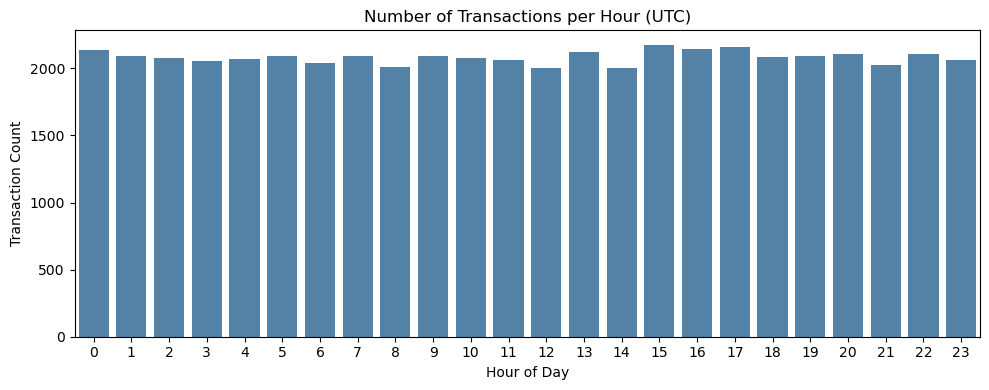

In [7]:
# visualize the number of transactions per hour (UTC)
import matplotlib.pyplot as plt
import seaborn as sns

hourly_counts = df["timestamp"].dt.hour.value_counts().sort_index()

plt.figure(figsize=(10, 4))
ax = sns.barplot(x=hourly_counts.index, y=hourly_counts.values, color="steelblue")
ax.set(
    title="Number of Transactions per Hour (UTC)",
    xlabel="Hour of Day",
    ylabel="Transaction Count",
)
plt.tight_layout()
plt.show()

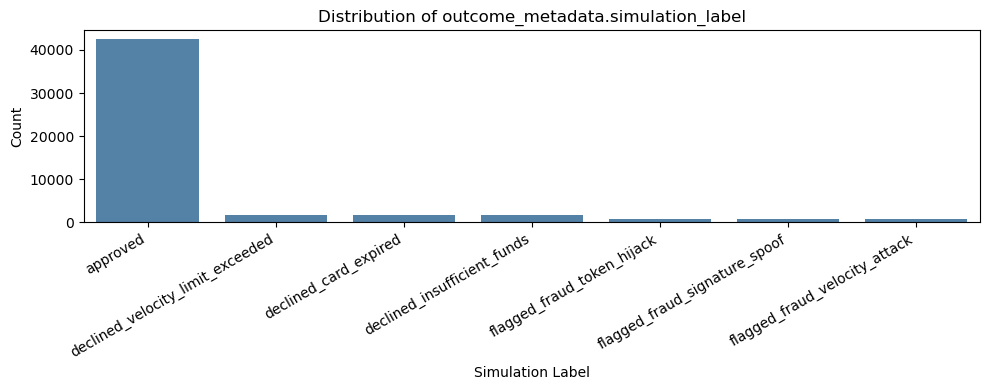

In [8]:
# plot a histogram of outcome_metadata.simulation_label values

plt.figure(figsize=(10, 4))
ax = sns.countplot(
    data=df,
    x="outcome_metadata.simulation_label",
    order=df["outcome_metadata.simulation_label"].value_counts().index,
    color="steelblue",
)
ax.set(
    title="Distribution of outcome_metadata.simulation_label",
    xlabel="Simulation Label",
    ylabel="Count",
)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()




Note that not all the non-approved outcomes signify that the transactions are tagged as fraudulent.  Some are standard and typical rejections based on card limits or insufficient funds.

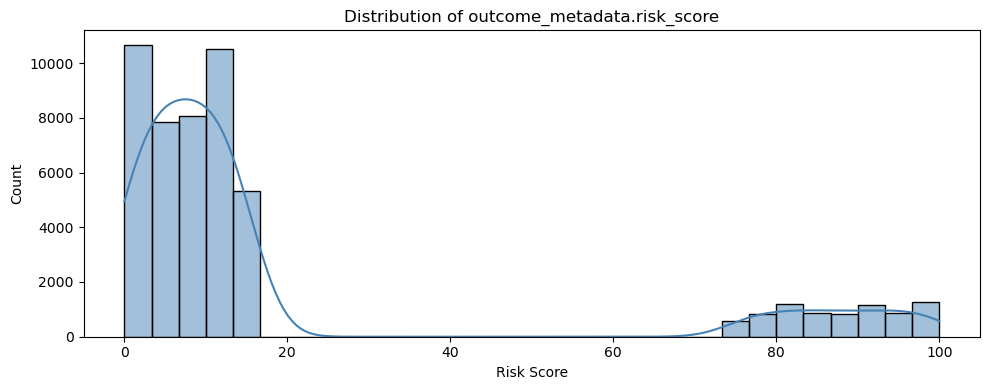

In [9]:
# plot a histogram of outcome_metadata.risk_score values
risk_scores = pd.to_numeric(df["outcome_metadata.risk_score"], errors="coerce").dropna()

plt.figure(figsize=(10, 4))
ax = sns.histplot(risk_scores, bins=30, color="steelblue", kde=True)
ax.set(
    title="Distribution of outcome_metadata.risk_score",
    xlabel="Risk Score",
    ylabel="Count",
)
plt.tight_layout()
plt.show()

In [10]:
# list rows with outcome_metadata.risk_score greater than 80 to begin to understand what the risk score implies
high_risk_rows = df[df["outcome_metadata.risk_score"] > 80]
high_risk_rows.head(10)

,transaction_id,timestamp,outcome_metadata.simulation_label,outcome_metadata.risk_score,initiation.acp_version,initiation.agent.id,initiation.agent.provider,initiation.cart.items,initiation.shipping_address.postal_code,initiation.shipping_address.country,...,proposal.totals.tax,proposal.totals.total,proposal.totals.currency,settlement.action,settlement.payment_token.token_id,settlement.payment_token.network_provider,settlement.payment_token.scoped_amount,settlement.payment_token.currency,settlement.buyer_verification.protocol,settlement.buyer_verification.mandate_signature
14,tx_acp_e881486a15ec,2026-10-07 16:01:21+00:00,declined_insufficient_funds,89,2026-04-17,agent_claude_v4,AI_Corp,"[{'sku': 'sku_iphone_17_pro', 'quantity': 1, '...",67368,US,...,98.92,1297.92,USD,payment_failed,spt_live_declined_6ad6bb8cf2,stripe_acp_v1,1297.92,USD,AP2,sig_ed25519_89a88a3f5a
39,tx_acp_f45c84d77d68,2026-10-07 19:22:21+00:00,declined_velocity_limit_exceeded,93,2026-04-17,agent_claude_v4,AI_Corp,"[{'sku': 'sku_vintage_tee_gr_l', 'quantity': 1...",74911,US,...,2.15,33.15,USD,payment_failed,spt_live_declined_e313263058,stripe_acp_v1,33.15,USD,AP2,sig_ed25519_bd87d710ac
60,tx_acp_f6b501ee60db,2026-10-08 06:35:21+00:00,declined_insufficient_funds,87,2026-04-17,agent_chatgpt_v5,AI_Corp,"[{'sku': 'sku_leather_boots_10', 'quantity': 2...",47403,US,...,19.80,259.80,USD,payment_failed,spt_live_declined_3780ce70c6,stripe_acp_v1,259.80,USD,AP2,sig_ed25519_ed555851be
92,tx_acp_52d35705e30d,2026-10-07 18:51:21+00:00,declined_insufficient_funds,97,2026-04-17,agent_claude_v4,AI_Corp,"[{'sku': 'sku_leather_boots_10', 'quantity': 2...",37730,US,...,19.80,259.80,USD,payment_failed,spt_live_declined_db2288cc65,stripe_acp_v1,259.80,USD,AP2,sig_ed25519_6846aed10b
95,tx_acp_d82bfce47d68,2026-10-08 10:12:21+00:00,declined_insufficient_funds,96,2026-04-17,agent_claude_v4,AI_Corp,"[{'sku': 'sku_vintage_tee_gr_l', 'quantity': 1...",35319,US,...,2.15,33.15,USD,payment_failed,spt_live_declined_38482dd542,stripe_acp_v1,33.15,USD,AP2,sig_ed25519_b2af8eedb9
101,tx_acp_f8db0a9b5e23,2026-10-07 17:27:21+00:00,declined_card_expired,98,2026-04-17,agent_chatgpt_v5,AI_Corp,"[{'sku': 'sku_leather_boots_10', 'quantity': 1...",55383,US,...,9.90,129.90,USD,payment_failed,spt_live_declined_427d1e46f0,stripe_acp_v1,129.90,USD,AP2,sig_ed25519_b0c110f4c0
104,tx_acp_0bfeeadebba6,2026-10-08 14:25:21+00:00,declined_insufficient_funds,89,2026-04-17,agent_chatgpt_v5,AI_Corp,"[{'sku': 'sku_vintage_tee_gr_l', 'quantity': 1...",26756,US,...,2.15,33.15,USD,payment_failed,spt_live_declined_8f0a856134,stripe_acp_v1,33.15,USD,AP2,sig_ed25519_f993a6ed29
113,tx_acp_b0a5b69d8364,2026-10-08 07:14:21+00:00,declined_velocity_limit_exceeded,95,2026-04-17,agent_claude_v4,AI_Corp,"[{'sku': 'sku_vintage_tee_gr_l', 'quantity': 1...",96583,US,...,2.15,33.15,USD,payment_failed,spt_live_declined_82a4667e4a,stripe_acp_v1,33.15,USD,AP2,sig_ed25519_43c2b78234
117,tx_acp_6a7237baf2df,2026-10-08 08:56:21+00:00,flagged_fraud_token_hijack,93,2026-04-17,agent_claude_v4,AI_Corp,"[{'sku': 'sku_vintage_tee_gr_l', 'quantity': 2...",25635,US,...,4.29,61.29,USD,gateway_rejected,spt_hijacked_or_expired,stripe_acp_v1,0.01,USD,AP2,sig_ed25519_773dbdd473
124,tx_acp_d64fff10572d,2026-10-08 05:31:21+00:00,flagged_fraud_signature_spoof,82,2026-04-17,agent_chatgpt_v5,AI_Corp,"[{'sku': 'sku_vintage_tee_gr_l', 'quantity': 1...",83768,US,...,2.15,33.15,USD,gateway_rejected,spt_hijacked_or_expired,stripe_acp_v1,33.15,USD,AP2,sig_INVALID_MALFORMED_DATA


In [11]:
# list rows with outcome_metadata.simulation_label containing "fraud"
fraud_rows = df[df["outcome_metadata.simulation_label"].str.contains("fraud", case=False, na=False)]    
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
fraud_rows.head(10)


,transaction_id,timestamp,outcome_metadata.simulation_label,outcome_metadata.risk_score,initiation.acp_version,initiation.agent.id,initiation.agent.provider,initiation.cart.items,initiation.shipping_address.postal_code,initiation.shipping_address.country,proposal.status,proposal.totals.subtotal,proposal.totals.shipping,proposal.totals.tax,proposal.totals.total,proposal.totals.currency,settlement.action,settlement.payment_token.token_id,settlement.payment_token.network_provider,settlement.payment_token.scoped_amount,settlement.payment_token.currency,settlement.buyer_verification.protocol,settlement.buyer_verification.mandate_signature
2,tx_acp_36bad9ae0e41,2026-10-08 01:24:21+00:00,flagged_fraud_signature_spoof,75,2026-04-17,agent_chatgpt_v5,AI_Corp,"[{'sku': 'sku_vintage_tee_gr_l', 'quantity': 2, 'unit_price': 26.0, 'currency': 'USD'}]",76166,US,security_flagged,52.00,5.0,4.29,61.29,USD,gateway_rejected,spt_hijacked_or_expired,stripe_acp_v1,61.29,USD,AP2,sig_ed25519_f06b23748f
23,tx_acp_a5376d4fd45b,2026-10-08 07:37:21+00:00,flagged_fraud_signature_spoof,80,2026-04-17,agent_claude_v4,AI_Corp,"[{'sku': 'sku_vintage_tee_gr_l', 'quantity': 2, 'unit_price': 26.0, 'currency': 'USD'}]",14796,US,security_flagged,52.00,5.0,4.29,61.29,USD,gateway_rejected,spt_hijacked_or_expired,stripe_acp_v1,61.29,USD,AP2,sig_INVALID_MALFORMED_DATA
64,tx_acp_8e4cb6b2c4be,2026-10-07 21:32:21+00:00,flagged_fraud_token_hijack,76,2026-04-17,agent_chatgpt_v5,AI_Corp,"[{'sku': 'sku_wireless_buds_v2', 'quantity': 2, 'unit_price': 89.99, 'currency': 'USD'}]",58666,US,security_flagged,179.98,0.0,14.85,194.83,USD,gateway_rejected,spt_hijacked_or_expired,stripe_acp_v1,0.01,USD,AP2,sig_ed25519_d38c951b41
117,tx_acp_6a7237baf2df,2026-10-08 08:56:21+00:00,flagged_fraud_token_hijack,93,2026-04-17,agent_claude_v4,AI_Corp,"[{'sku': 'sku_vintage_tee_gr_l', 'quantity': 2, 'unit_price': 26.0, 'currency': 'USD'}]",25635,US,security_flagged,52.00,5.0,4.29,61.29,USD,gateway_rejected,spt_hijacked_or_expired,stripe_acp_v1,0.01,USD,AP2,sig_ed25519_773dbdd473
124,tx_acp_d64fff10572d,2026-10-08 05:31:21+00:00,flagged_fraud_signature_spoof,82,2026-04-17,agent_chatgpt_v5,AI_Corp,"[{'sku': 'sku_vintage_tee_gr_l', 'quantity': 1, 'unit_price': 26.0, 'currency': 'USD'}]",83768,US,security_flagged,26.00,5.0,2.15,33.15,USD,gateway_rejected,spt_hijacked_or_expired,stripe_acp_v1,33.15,USD,AP2,sig_INVALID_MALFORMED_DATA
172,tx_acp_c79ef8978420,2026-10-08 13:24:21+00:00,flagged_fraud_velocity_attack,81,2026-04-17,unknown_bot_net,AI_Corp,"[{'sku': 'sku_leather_boots_10', 'quantity': 50, 'unit_price': 120.0, 'currency': 'USD'}]",22954,US,security_flagged,240.00,0.0,19.80,12000.00,USD,gateway_rejected,spt_hijacked_or_expired,stripe_acp_v1,259.80,USD,AP2,sig_ed25519_6ec64e4388
184,tx_acp_abee5fe547b3,2026-10-07 17:27:21+00:00,flagged_fraud_signature_spoof,87,2026-04-17,agent_chatgpt_v5,AI_Corp,"[{'sku': 'sku_leather_boots_10', 'quantity': 1, 'unit_price': 120.0, 'currency': 'USD'}]",87068,US,security_flagged,120.00,0.0,9.90,129.90,USD,gateway_rejected,spt_hijacked_or_expired,stripe_acp_v1,129.90,USD,AP2,sig_INVALID_MALFORMED_DATA
197,tx_acp_de7d519038ac,2026-10-07 18:58:21+00:00,flagged_fraud_signature_spoof,96,2026-04-17,agent_claude_v4,AI_Corp,"[{'sku': 'sku_vintage_tee_gr_l', 'quantity': 1, 'unit_price': 26.0, 'currency': 'USD'}]",14780,US,security_flagged,26.00,5.0,2.15,33.15,USD,gateway_rejected,spt_hijacked_or_expired,stripe_acp_v1,33.15,USD,AP2,sig_INVALID_MALFORMED_DATA
214,tx_acp_662d54dee86c,2026-10-08 02:38:21+00:00,flagged_fraud_signature_spoof,80,2026-04-17,agent_chatgpt_v5,AI_Corp,"[{'sku': 'sku_wireless_buds_v2', 'quantity': 1, 'unit_price': 89.99, 'currency': 'USD'}]",12734,US,security_flagged,89.99,5.0,7.42,102.41,USD,gateway_rejected,spt_hijacked_or_expired,stripe_acp_v1,102.41,USD,AP2,sig_INVALID_MALFORMED_DATA
238,tx_acp_e709224ed9c7,2026-10-08 15:14:21+00:00,flagged_fraud_signature_spoof,94,2026-04-17,agent_chatgpt_v5,AI_Corp,"[{'sku': 'sku_leather_boots_10', 'quantity': 2,

Begin data manipulation, feature selection and data preparation for better ML model performance.

In [12]:
# create a new dataframe based on df with a new column "fraud" with integer values (0 or 1) indicating whether the simulation_label contains "fraud"
dfnew = df.copy()
dfnew["fraud"] = (
    dfnew["outcome_metadata.simulation_label"]
    .str.contains("fraud", case=False, na=False)
    .astype(int)
 )
dfnew.head(10)

,transaction_id,timestamp,outcome_metadata.simulation_label,outcome_metadata.risk_score,initiation.acp_version,initiation.agent.id,initiation.agent.provider,initiation.cart.items,initiation.shipping_address.postal_code,initiation.shipping_address.country,proposal.status,proposal.totals.subtotal,proposal.totals.shipping,proposal.totals.tax,proposal.totals.total,proposal.totals.currency,settlement.action,settlement.payment_token.token_id,settlement.payment_token.network_provider,settlement.payment_token.scoped_amount,settlement.payment_token.currency,settlement.buyer_verification.protocol,settlement.buyer_verification.mandate_signature,fraud
0,tx_acp_c628f566022a,2026-10-07 22:28:21+00:00,approved,10,2026-04-17,agent_chatgpt_v5,AI_Corp,"[{'sku': 'sku_wireless_buds_v2', 'quantity': 2, 'unit_price': 89.99, 'currency': 'USD'}]",43960,US,proposal_created,179.98,0.0,14.85,194.83,USD,payment_settled,spt_live_a0da42858444408,stripe_acp_v1,194.83,USD,AP2,sig_ed25519_44c9c7d607,0
1,tx_acp_ddaaa6cc2a64,2026-10-08 12:03:21+00:00,approved,10,2026-04-17,agent_chatgpt_v5,AI_Corp,"[{'sku': 'sku_vintage_tee_gr_l', 'quantity': 2, 'unit_price': 26.0, 'currency': 'USD'}]",21013,US,proposal_created,52.00,5.0,4.29,61.29,USD,payment_settled,spt_live_7dbe22ef6cbe4a5,stripe_acp_v1,61.29,USD,AP2,sig_ed25519_62db8e4b24,0
2,tx_acp_36bad9ae0e41,2026-10-08 01:24:21+00:00,flagged_fraud_signature_spoof,75,2026-04-17,agent_chatgpt_v5,AI_Corp,"[{'sku': 'sku_vintage_tee_gr_l', 'quantity': 2, 'unit_price': 26.0, 'currency': 'USD'}]",76166,US,security_flagged,52.00,5.0,4.29,61.29,USD,gateway_rejected,spt_hijacked_or_expired,stripe_acp_v1,61.29,USD,AP2,sig_ed25519_f06b23748f,1
3,tx_acp_fba70b403661,2026-10-08 09:22:21+00:00,approved,7,2026-04-17,agent_claude_v4,AI_Corp,"[{'sku': 'sku_vintage_tee_gr_l', 'quantity': 1, 'unit_price': 26.0, 'currency': 'USD'}]",19337,US,proposal_created,26.00,5.0,2.15,33.15,USD,payment_settled,spt_live_128c2575c9fa44a,stripe_acp_v1,33.15,USD,AP2,sig_ed25519_d2015f291c,0
4,tx_acp_44291d2914ee,2026-10-07 20:41:21+00:00,approved,14,2026-04-17,agent_claude_v4,AI_Corp,"[{'sku': 'sku_vintage_tee_gr_l', 'quantity': 2, 'unit_price': 26.0, 'currency': 'USD'}]",30209,US,proposal_created,52.00,5.0,4.29,61.29,USD,payment_settled,spt_live_52306c42f22f4b8,stripe_acp_v1,61.29,USD,AP2,sig_ed25519_45096d5183,0
5,tx_acp_7828e74022d7,2026-10-08 01:00:21+00:00,approved,4,2026-04-17,agent_claude_v4,AI_Corp,"[{'sku': 'sku_vintage_tee_gr_l', 'quantity': 1, 'unit_price': 26.0, 'currency': 'USD'}]",43185,US,proposal_created,26.00,5.0,2.15,33.15,USD,payment_settled,spt_live_4cbf9eec94da428,stripe_acp_v1,33.15,USD,AP2,sig_ed25519_244a8867dc,0
6,tx_acp_b674883f8dbb,2026-10-08 00:30:21+00:00,approved,3,2026-04-17,agent_chatgpt_v5,AI_Corp,"[{'sku': 'sku_wireless_buds_v2', 'quantity': 2, 'unit_price': 89.99, 'currency': 'USD'}]",15089,US,proposal_created,179.98,0.0,14.85,194.83,USD,payment_settled,spt_live_5f865c7dffd347b,stripe_acp_v1,194.83,USD,AP2,sig_ed25519_6b2f7b531c,0
7,tx_acp_7196ba2688e5,2026-10-08 11:11:21+00:00,approved,15,2026-04-17,agent_chatgpt_v5,AI_Corp,"[{'sku': 'sku_vintage_tee_gr_l', 'quantity': 2, 'unit_price': 26.0, 'currency': 'USD'}]",21061,US,proposal_created,52.00,5.0,4.29,61.29,USD,payment_settled,spt_live_52a05ac2fbab44d,stripe_acp_v1,61.29,USD,AP2,sig_ed25519_35fdd7f27c,0
8,tx_acp_fd6600d8948f,2026-10-08 11:12:21+00:00,approved,2,2026-04-17,agent_claude_v4,AI_Corp,"[{'sku': 'sku_vintage_tee_gr_l', 'quantity': 2, 'unit_price': 26.0, 'currency': 'USD'}]",83543,US,proposal_created,52.00,5.0,4.29,61.29,USD,payment_settled,spt_live_22036edc3e1a410,stripe_acp_v1,61.29,USD,AP2,sig_ed25519_f91dc9261a,0
9,tx_acp_0bb5f2aebb3a,2026-10-07 21:39:21+00:00,approved,0,2026-04-17,agent_chatgpt_v5,AI_Corp,"[{'sku': 'sku_wireless_buds_v2', 'quantity': 1, 'unit_price': 89.99, 'currency': 'USD'}]",93601,US,proposal_created,89.99,5.0,7.42,102.41,USD,payment_settled,spt_live_7c9886be2421430,stripe_acp_v1,102.41,USD,AP2,sig_ed25519_9260b0f254,0


In [13]:
# remove columns from dfnew that are correlated with the fraud column or are unnecessary for analysis
# transaction_id	timestamp	outcome_metadata.risk_score initiation.cart.items settlement.action initiation.cart.items settlement.action
# drop columns unnecesary for the analysis
dfnew = dfnew.drop(columns=[
    "transaction_id","timestamp", "proposal.totals.tax", "proposal.totals.subtotal", "initiation.acp_version"])
# drop columns which will not be present BEFORE the transaction gateway sends it for processing
dfnew = dfnew.drop(columns=[
    "outcome_metadata.risk_score","initiation.cart.items","settlement.action","initiation.cart.items","settlement.action", "settlement.payment_token.token_id", "outcome_metadata.simulation_label", "proposal.status"])

dfnew.head(10)




,initiation.agent.id,initiation.agent.provider,initiation.shipping_address.postal_code,initiation.shipping_address.country,proposal.totals.shipping,proposal.totals.total,proposal.totals.currency,settlement.payment_token.network_provider,settlement.payment_token.scoped_amount,settlement.payment_token.currency,settlement.buyer_verification.protocol,settlement.buyer_verification.mandate_signature,fraud
0,agent_chatgpt_v5,AI_Corp,43960,US,0.0,194.83,USD,stripe_acp_v1,194.83,USD,AP2,sig_ed25519_44c9c7d607,0
1,agent_chatgpt_v5,AI_Corp,21013,US,5.0,61.29,USD,stripe_acp_v1,61.29,USD,AP2,sig_ed25519_62db8e4b24,0
2,agent_chatgpt_v5,AI_Corp,76166,US,5.0,61.29,USD,stripe_acp_v1,61.29,USD,AP2,sig_ed25519_f06b23748f,1
3,agent_claude_v4,AI_Corp,19337,US,5.0,33.15,USD,stripe_acp_v1,33.15,USD,AP2,sig_ed25519_d2015f291c,0
4,agent_claude_v4,AI_Corp,30209,US,5.0,61.29,USD,stripe_acp_v1,61.29,USD,AP2,sig_ed25519_45096d5183,0
5,agent_claude_v4,AI_Corp,43185,US,5.0,33.15,USD,stripe_acp_v1,33.15,USD,AP2,sig_ed25519_244a8867dc,0
6,agent_chatgpt_v5,AI_Corp,15089,US,0.0,194.83,USD,stripe_acp_v1,194.83,USD,AP2,sig_ed25519_6b2f7b531c,0
7,agent_chatgpt_v5,AI_Corp,21061,US,5.0,61.29,USD,stripe_acp_v1,61.29,USD,AP2,sig_ed25519_35fdd7f27c,0
8,agent_claude_v4,AI_Corp,83543,US,5.0,61.29,USD,stripe_acp_v1,61.29,USD,AP2,sig_ed25519_f91dc9261a,0
9,agent_chatgpt_v5,AI_Corp,93601,US,5.0,102.41,USD,stripe_acp_v1,102.41,USD,AP2,sig_ed25519_9260b0f254,0


In [14]:
# create new field "invalid_mandate" which will be 1 if if value contains the word "INVALID" and 0 otherwise
dfnew["invalid_mandate"] = (
    dfnew["settlement.buyer_verification.mandate_signature"]
    .str.contains("INVALID", case=False, na=False)
    .astype(int)
 )
dfnew.head(20)

,initiation.agent.id,initiation.agent.provider,initiation.shipping_address.postal_code,initiation.shipping_address.country,proposal.totals.shipping,proposal.totals.total,proposal.totals.currency,settlement.payment_token.network_provider,settlement.payment_token.scoped_amount,settlement.payment_token.currency,settlement.buyer_verification.protocol,settlement.buyer_verification.mandate_signature,fraud,invalid_mandate
0,agent_chatgpt_v5,AI_Corp,43960,US,0.0,194.83,USD,stripe_acp_v1,194.83,USD,AP2,sig_ed25519_44c9c7d607,0,0
1,agent_chatgpt_v5,AI_Corp,21013,US,5.0,61.29,USD,stripe_acp_v1,61.29,USD,AP2,sig_ed25519_62db8e4b24,0,0
2,agent_chatgpt_v5,AI_Corp,76166,US,5.0,61.29,USD,stripe_acp_v1,61.29,USD,AP2,sig_ed25519_f06b23748f,1,0
3,agent_claude_v4,AI_Corp,19337,US,5.0,33.15,USD,stripe_acp_v1,33.15,USD,AP2,sig_ed25519_d2015f291c,0,0
4,agent_claude_v4,AI_Corp,30209,US,5.0,61.29,USD,stripe_acp_v1,61.29,USD,AP2,sig_ed25519_45096d5183,0,0
5,agent_claude_v4,AI_Corp,43185,US,5.0,33.15,USD,stripe_acp_v1,33.15,USD,AP2,sig_ed25519_244a8867dc,0,0
6,agent_chatgpt_v5,AI_Corp,15089,US,0.0,194.83,USD,stripe_acp_v1,194.83,USD,AP2,sig_ed25519_6b2f7b531c,0,0
7,agent_chatgpt_v5,AI_Corp,21061,US,5.0,61.29,USD,stripe_acp_v1,61.29,USD,AP2,sig_ed25519_35fdd7f27c,0,0
8,agent_claude_v4,AI_Corp,83543,US,5.0,61.29,USD,stripe_acp_v1,61.29,USD,AP2,sig_ed25519_f91dc9261a,0,0
9,agent_chatgpt_v5,AI_Corp,93601,US,5.0,102.41,USD,stripe_acp_v1,102.41,USD,AP2,sig_ed25519_9260b0f254,0,0


In [15]:
# remove the settlement.buyer_verification.mandate_signature column
dfnew = dfnew.drop(columns=["settlement.buyer_verification.mandate_signature"])

In [16]:
# change postal code to numeric type, replacing non-numeric values with NaN
dfnew["initiation.shipping_address.postal_code"] = pd.to_numeric(dfnew["initiation.shipping_address.postal_code"], errors="coerce")


In [17]:
# Encode all categorical columns in dfnew using one-hot encoding with integer indicators
dfencoded = pd.get_dummies(dfnew, drop_first=True, dtype=int)
dfencoded.head(10)

,initiation.shipping_address.postal_code,proposal.totals.shipping,proposal.totals.total,settlement.payment_token.scoped_amount,fraud,invalid_mandate,initiation.agent.id_agent_claude_v4,initiation.agent.id_unknown_bot_net
0,43960,0.0,194.83,194.83,0,0,0,0
1,21013,5.0,61.29,61.29,0,0,0,0
2,76166,5.0,61.29,61.29,1,0,0,0
3,19337,5.0,33.15,33.15,0,0,1,0
4,30209,5.0,61.29,61.29,0,0,1,0
5,43185,5.0,33.15,33.15,0,0,1,0
6,15089,0.0,194.83,194.83,0,0,0,0
7,21061,5.0,61.29,61.29,0,0,0,0
8,83543,5.0,61.29,61.29,0,0,1,0
9,93601,5.0,102.41,102.41,0,0,0,0


In [18]:
# create a new column "scoped_vs_proposal_relation" which divides the scoped amount by the proposal.totals.total and rounds to zero decimal places.
# This new created column will help in understanding the proportion of the scoped amount relative to the total proposal amount, a possible fraud indicator
dfencoded["scoped_vs_proposal_relation"] = dfencoded["proposal.totals.total"]/dfencoded["settlement.payment_token.scoped_amount"].round(2)
dfencoded.head(20)

,initiation.shipping_address.postal_code,proposal.totals.shipping,proposal.totals.total,settlement.payment_token.scoped_amount,fraud,invalid_mandate,initiation.agent.id_agent_claude_v4,initiation.agent.id_unknown_bot_net,scoped_vs_proposal_relation
0,43960,0.0,194.83,194.83,0,0,0,0,1.0
1,21013,5.0,61.29,61.29,0,0,0,0,1.0
2,76166,5.0,61.29,61.29,1,0,0,0,1.0
3,19337,5.0,33.15,33.15,0,0,1,0,1.0
4,30209,5.0,61.29,61.29,0,0,1,0,1.0
5,43185,5.0,33.15,33.15,0,0,1,0,1.0
6,15089,0.0,194.83,194.83,0,0,0,0,1.0
7,21061,5.0,61.29,61.29,0,0,0,0,1.0
8,83543,5.0,61.29,61.29,0,0,1,0,1.0
9,93601,5.0,102.41,102.41,0,0,0,0,1.0


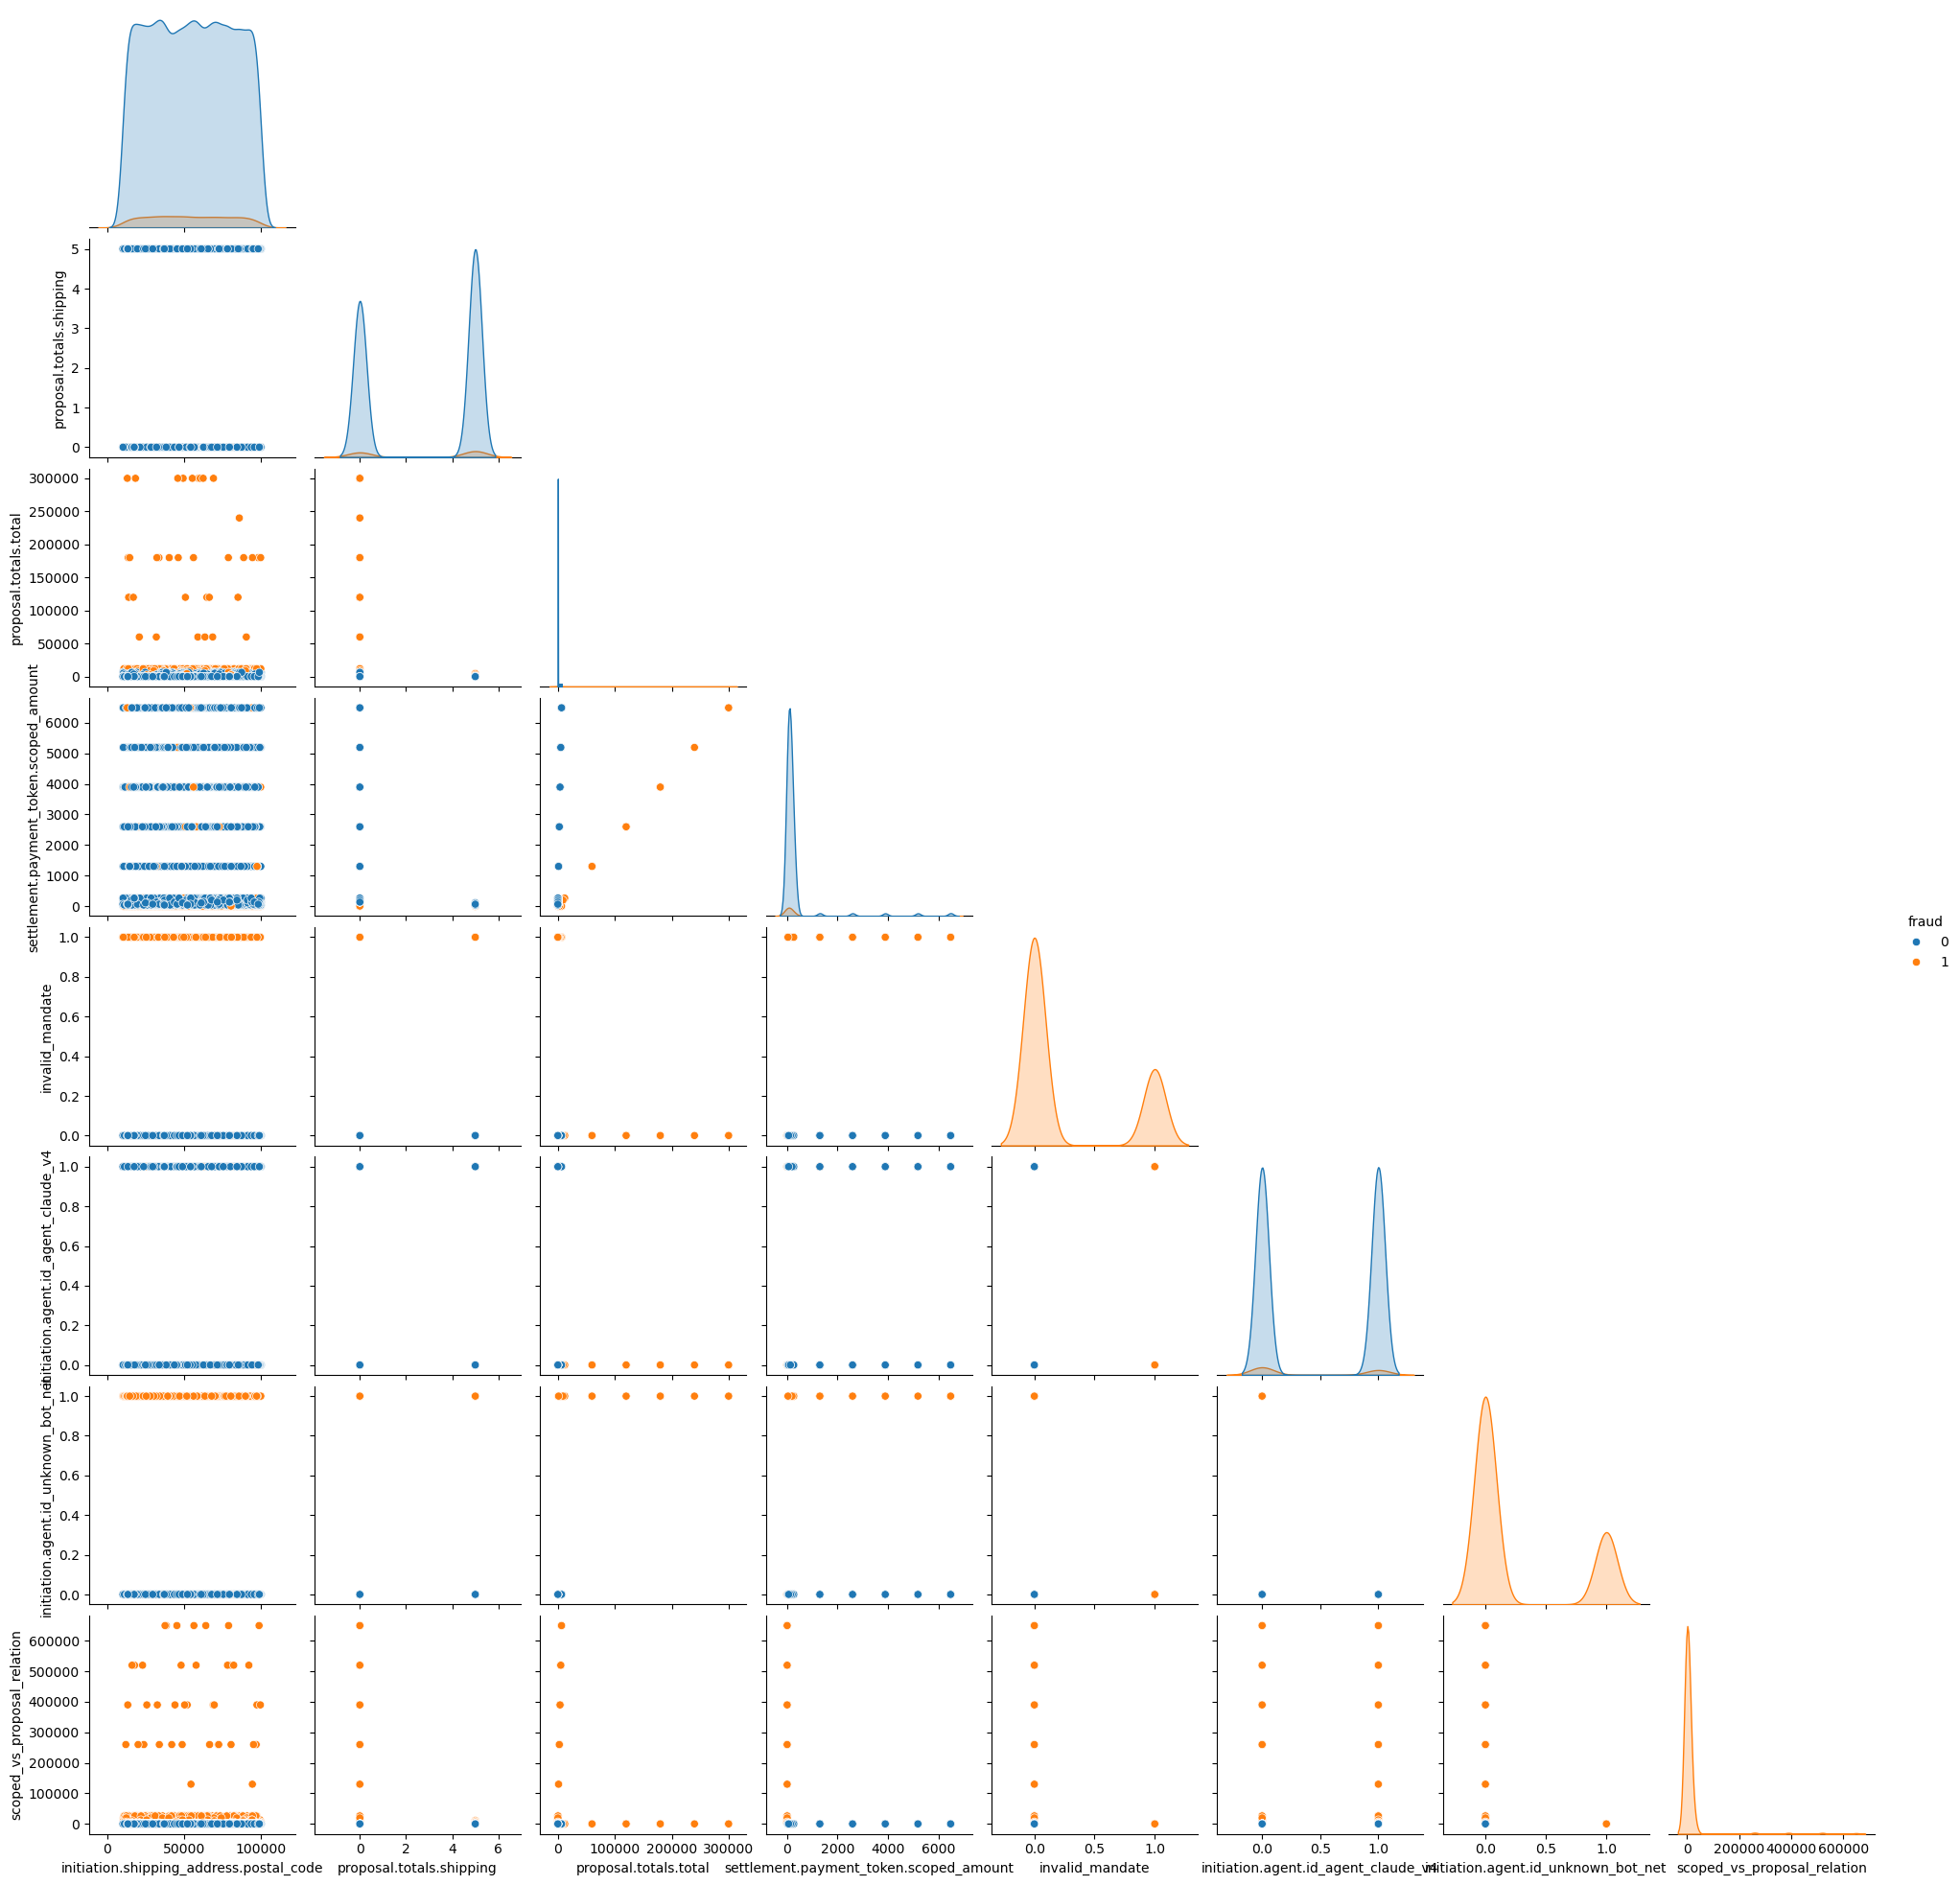

In [19]:
# plot a pairplot of the dfencoded dataframe, with hue set to the fraud column
sns.pairplot(dfencoded, hue="fraud", diag_kind="kde", corner=True)


<Axes: >

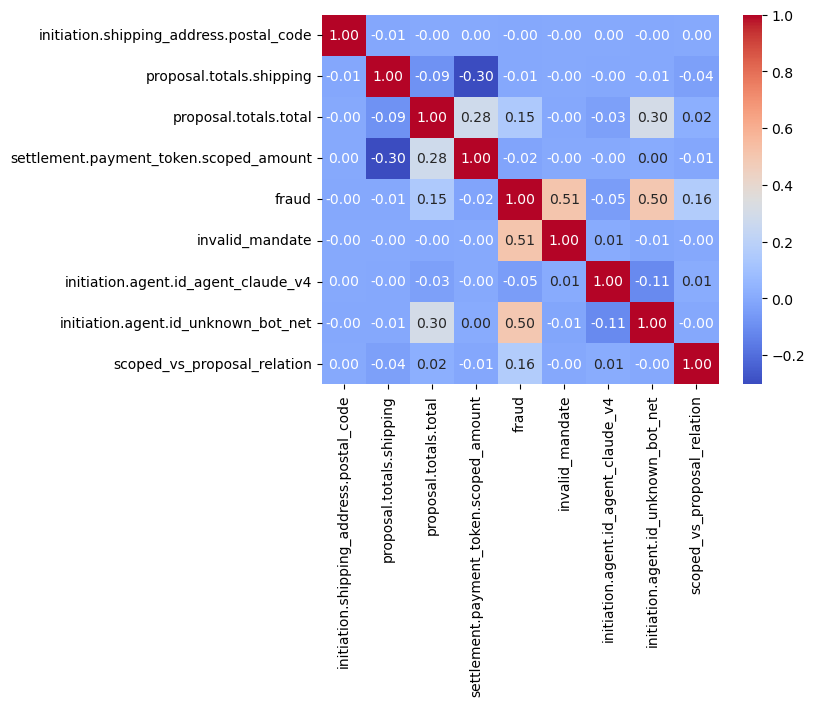

In [20]:
# perform a correlation analysis on the dfencoded dataframe, and plot a heatmap of the correlation matrix
correlation_matrix = dfencoded.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)


We begin to notice that the modified dataset could work with some of the features showing some correlation with fraud, but no feature directly correlated with fraud, which obviously would not happen in a real scenario.

We begin to try models to create a BASELINE scenario.

In [21]:
# separate into train and test sets, with 80% of the data in the training set and 20% in the test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    dfencoded.drop(columns=["fraud"]), dfencoded["fraud"], test_size=0.2, random_state=42
)
# show shape of training and test sets
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (40000, 8)
X_test shape: (10000, 8)


In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression())
])
model.fit(X_train, y_train)

,steps,"[('scaler', ...), ('logreg', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [23]:
#model = LogisticRegression(max_iter=1000).fit(X_train, y_train)
# test model with test set and show accuracy score
from sklearn.metrics import accuracy_score
model_predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, model_predictions)
print(f"Model accuracy: {accuracy:.4f}")



Model accuracy: 0.9900


In [24]:
# show parameters of the model and coefficients 

params_df = pd.DataFrame(
    model.named_steps["logreg"].get_params().items(),
    columns=["parameter", "value"]
)

coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": model.named_steps["logreg"].coef_[0]
})

intercept_df = pd.DataFrame({
    "feature": ["intercept"],
    "coefficient": [model.named_steps["logreg"].intercept_[0]]
})

all_coef_df = pd.concat([intercept_df, coef_df], ignore_index=True)

#print(params_df)
print(all_coef_df)



                                   feature  coefficient
0                                intercept    -2.793942
1  initiation.shipping_address.postal_code    -0.010015
2                 proposal.totals.shipping     0.051138
3                    proposal.totals.total     0.798803
4   settlement.payment_token.scoped_amount    -0.254454
5                          invalid_mandate     3.996748
6      initiation.agent.id_agent_claude_v4     0.059220
7      initiation.agent.id_unknown_bot_net     3.781344
8              scoped_vs_proposal_relation    17.572340


In [25]:
# select the top 5 features with the highest absolute coefficients
top_features = all_coef_df.iloc[1:].reindex(all_coef_df.iloc[1:]["coefficient"].abs().sort_values(ascending=False).index).head(5)
print(top_features)


                                  feature  coefficient
8             scoped_vs_proposal_relation    17.572340
5                         invalid_mandate     3.996748
7     initiation.agent.id_unknown_bot_net     3.781344
3                   proposal.totals.total     0.798803
4  settlement.payment_token.scoped_amount    -0.254454
